# Fit and visualize a Doohan hierarchical LMDP

This notebook reproduces the data setup and trial assembly from `doohan_trial_lmdp.ipynb`, fits a fresh distributed hierarchy to those trials with Adam, materializes the best parameter snapshot as a new NumPy hierarchy, and visualizes that fitted hierarchy with the hierarchical diagnostic plots.


## 1. Setup paths, select sessions, and build the shared maze

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    raise FileNotFoundError("Run this notebook from the project or notebook directory")

sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT))
from andrew_mlmdp import (  # noqa: E402
    DoohanDataset,
    Environment,
    NMFConfig,
    NMFConnectivityConfig,
    Parameters,
    SubgoalBasis,
    discover_subgoals,
    fittable_parameters,
    score_flat_dataset,
    score_hierarchy_dataset,
    soft_parameters,
)
from andrew_mlmdp import (  # noqa: E402
    plotting as viz,
)

GRIDMAZE_DATA = (
    PROJECT_ROOT / "external" / "GridMaze-mFC-ephys-DATA" / "data"
)

SUBJECT_IDS = ["m2"]
MAZE_NAME = "maze_1"
START_DATE = "2022-06-30"
END_DATE = "2022-07-05"

movement_dataset = DoohanDataset.from_data_root(
    GRIDMAZE_DATA,
    subject_ids=SUBJECT_IDS,
    start_date=START_DATE,
    end_date=END_DATE,
    maze_name=MAZE_NAME,
)
sessions = movement_dataset.sessions
labeled_maze = movement_dataset.definition
maze = labeled_maze.maze
environment = Environment(maze)

print(f"sessions: {len(sessions)}")
print(f"maze: {movement_dataset.maze_name}")
print(f"tower grid shape: {maze.shape}")
print(f"physical states: {len(maze.free_cells)}")

sessions: 6
maze: maze_1
tower grid shape: (7, 7)
physical states: 49


## 2. Inspect the assembled navigation trials

The Doohan movement dataset owns session discovery and trial extraction. It removes missing positions and bridge labels, collapses consecutive towers, converts labels to coordinates, truncates each trajectory at its first goal entry, and retains malformed sessions or trials as explicit exclusions.

In [2]:
movement_trials = list(movement_dataset.trials)
exclusion_rows = [
    {
        "session": exclusion.session_id,
        "trial": exclusion.trial_id,
        "goal": exclusion.goal_label,
        "transitions": 0,
        "flat_log_likelihood": float("nan"),
        "hierarchical_log_likelihood": float("nan"),
        "status": "excluded",
        "exclusion_reason": f"data: {exclusion.reason}",
    }
    for exclusion in movement_dataset.exclusions
]

print(f"valid trials: {len(movement_trials)}")
print(f"data exclusions: {len(exclusion_rows)}")

valid trials: 404
data exclusions: 0


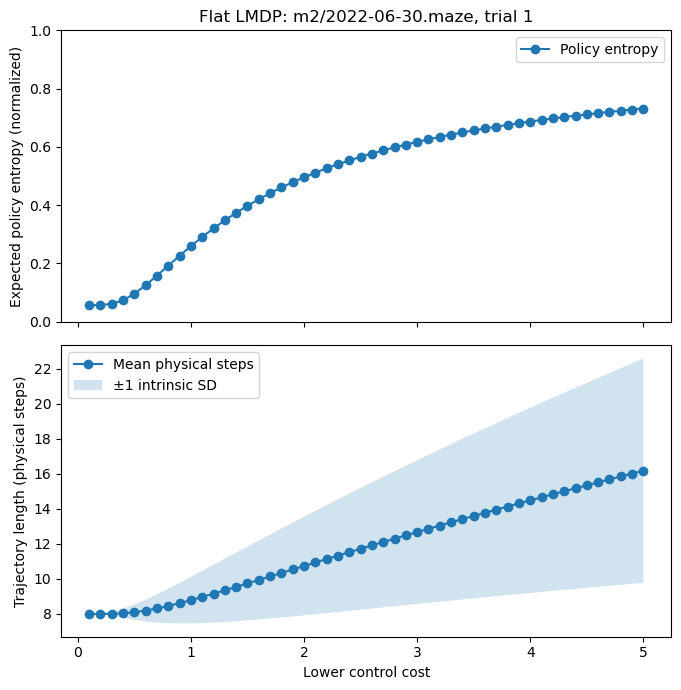

In [3]:
FLAT_SWEEP_TRIAL_INDEX = 0
FLAT_CONTROL_COST_SWEEP_VALUES = np.linspace(0.1, 5.0, 50)

flat_sweep_trial = movement_trials[FLAT_SWEEP_TRIAL_INDEX]
flat_sweep_start = flat_sweep_trial.trajectory[0]
flat_sweep_goal = flat_sweep_trial.goal

flat_solutions = tuple(
    [
        environment.solve(
            flat_sweep_goal,
            parameters=Parameters(
                lower_control_cost=float(control_cost),
            ),
        )
        for control_cost in FLAT_CONTROL_COST_SWEEP_VALUES
    ]
)
flat_length_moments = np.asarray(
    [
        solution.trajectory_length_moments(flat_sweep_start)
        for solution in flat_solutions
    ],
    dtype=np.float64,
)
flat_mean_steps, flat_step_sd = flat_length_moments.T
flat_normalized_entropy = np.asarray(
    [
        solution.policy_entropy(flat_sweep_start).normalized_entropy
        for solution in flat_solutions
    ],
    dtype=np.float64,
)

fig, (flat_entropy_ax, flat_length_ax) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(7, 7),
)
flat_entropy_ax.plot(
    FLAT_CONTROL_COST_SWEEP_VALUES,
    flat_normalized_entropy,
    marker="o",
    label="Policy entropy",
)
flat_entropy_ax.set(
    ylabel="Expected policy entropy (normalized)",
    ylim=(0.0, 1.0),
    title=(
        f"Flat LMDP: {flat_sweep_trial.session_id}, "
        f"trial {flat_sweep_trial.trial_id}"
    ),
)
flat_entropy_ax.legend()

flat_length_ax.plot(
    FLAT_CONTROL_COST_SWEEP_VALUES,
    flat_mean_steps,
    marker="o",
    label="Mean physical steps",
)
flat_length_ax.fill_between(
    FLAT_CONTROL_COST_SWEEP_VALUES,
    flat_mean_steps - flat_step_sd,
    flat_mean_steps + flat_step_sd,
    alpha=0.2,
    label="±1 intrinsic SD",
)
flat_length_ax.set(
    xlabel="Lower control cost",
    ylabel="Trajectory length (physical steps)",
)
flat_length_ax.legend()
fig.tight_layout()
plt.show()

## 3. Discover the connected distributed basis and construct the initial hierarchy

Discovery runs seeded stochastic KL-NMF, persistently masks secondary islands in each component's tie-safe 95%-mass support, and uses deterministic positive fallbacks when MU reaches a zero-locked boundary. The first table reports one row per restart. The following tables summarize the selected restart and its component supports before the selected basis enters the hierarchy.

selected NMF restart: 3 | seed: 3


,seed,selected,eligible,reason,KL_initial,KL_connected,delta_KL,prune_refit_rounds,all_fits_converged,positive_fallback_attempts,positive_fallback_successes,fully_forbidden_states,maximum_forbidden_mass_fraction
restart,,,,,,,,,,,,,
0,0,False,True,None,76.709288,72.906887,-3.802400,1,True,0,0,0,0.439027
1,1,False,False,positive_fallback_failed,81.592253,NaN,NaN,2,True,9,5,0,0.476296
2,2,False,True,None,82.083843,75.277210,-6.806633,3,True,6,2,0,0.961308
3,3,True,True,None,81.435729,72.288024,-9.147705,2,True,3,3,0,0.390635
4,4,False,True,None,79.382472,73.629677,-5.752795,2,True,0,0,0,0.476199


,rank,seed,KL_initial,KL_connected,delta_KL_restart,best_unconstrained_restart,best_unconstrained_KL,delta_KL_rank,prune_refit_rounds,fit_iterations,positive_fallback_attempts,positive_fallback_successes
restart,,,,,,,,,,,,
3,8,3,81.435729,72.288024,-9.147705,0,76.709288,-4.421264,2,"(90, 90, 70, 60, 30)",3,3


,forbidden_mass_fraction,effective_support_size,effective_support_fraction,effective_support_connected
component,,,,
0,0.000000,9.399597,0.191829,True
1,0.372692,5.266438,0.107478,True
2,0.390635,6.425561,0.131134,True
3,0.000000,6.594569,0.134583,True
4,0.318018,4.348346,0.088742,True
5,0.305893,5.559193,0.113453,True
6,0.287855,8.313428,0.169662,True
7,0.375558,7.007906,0.143018,True


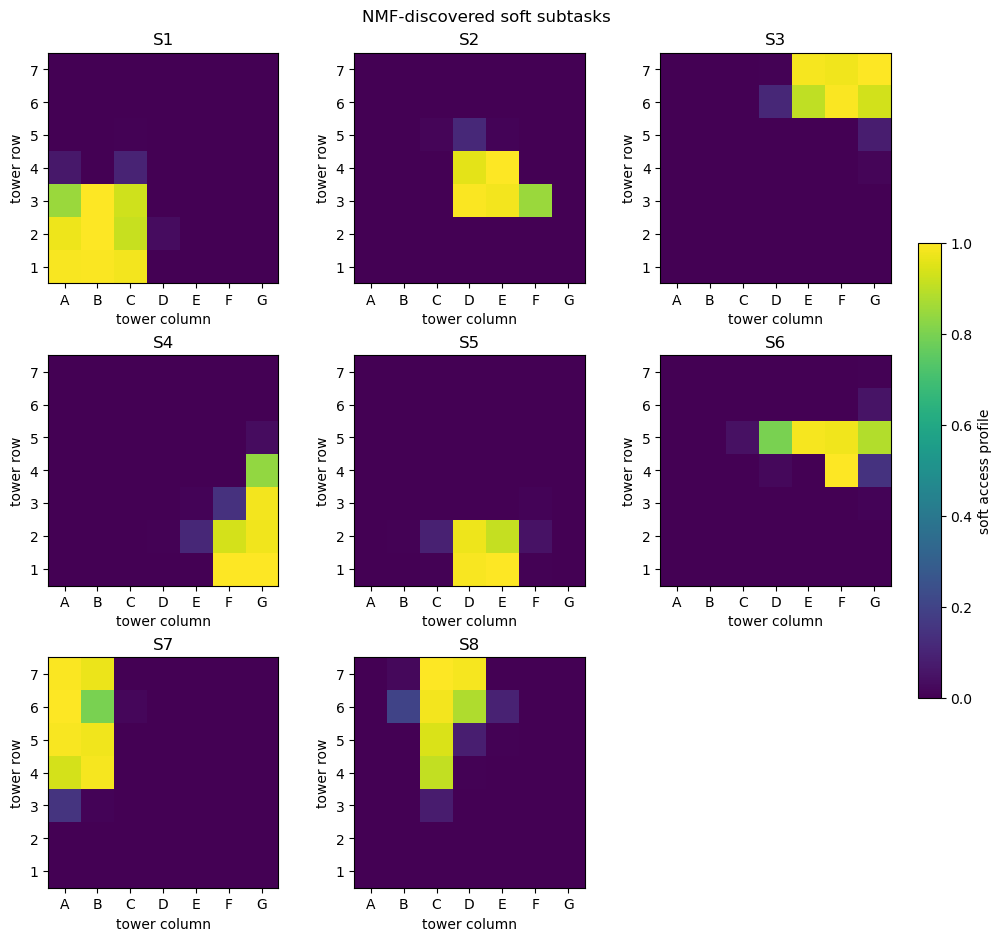

active fitted parameters: ('lower_control_cost', 'upper_control_cost', 'alpha', 'beta', 'core_threshold', 'core_exponent')


In [4]:
from andrew_mlmdp.hierarchy import (
    sample_rollouts,
    sweep_diagnostics,
)

DISCOVERY_RANK = 8
DISCOVERY_CONTROL_COST = 1
DISCOVERY_SUPPORT_MASS = 0.95
DISCOVERY_MAX_PRUNE_REFITS = 3
DISCOVERY_POSITIVE_FALLBACK_ATTEMPTS = 3
DISCOVERY_MAX_ITER = 2000
DISCOVERY_TOLERANCE = 1e-5
DISCOVERY_RESTART_SEEDS = tuple(range(5))

soft_study = discover_subgoals(
    environment,
    ranks=(DISCOVERY_RANK,),
    parameters=NMFConfig(control_cost=DISCOVERY_CONTROL_COST),
    connectivity=NMFConnectivityConfig(
        support_mass=DISCOVERY_SUPPORT_MASS,
        max_prune_refits=DISCOVERY_MAX_PRUNE_REFITS,
        positive_fallback_attempts=(
            DISCOVERY_POSITIVE_FALLBACK_ATTEMPTS
        ),
        restart_seeds=DISCOVERY_RESTART_SEEDS,
    ),
    max_iter=DISCOVERY_MAX_ITER,
    tolerance=DISCOVERY_TOLERANCE,
)
soft_rank_result = soft_study.rank_result(DISCOVERY_RANK)
soft_discovery = soft_rank_result.discovery
if soft_discovery is None:
    failure_summary = {
        restart.seed: restart.reason
        for restart in soft_rank_result.restarts
    }
    raise RuntimeError(
        f"Every connected NMF restart was excluded: {failure_summary}"
    )

selected_nmf_restart = soft_rank_result.restarts[
    soft_rank_result.selected_restart_id
]
assert selected_nmf_restart.eligible
assert selected_nmf_restart.connected_profiles is not None
assert selected_nmf_restart.connected_task_weights is not None
assert np.all(selected_nmf_restart.final_support_connected)
assert np.array_equal(
    soft_discovery.profiles,
    selected_nmf_restart.connected_profiles,
)
assert np.all(
    selected_nmf_restart.connected_profiles[
        selected_nmf_restart.forbidden_mask
    ]
    == 0.0
)

nmf_run_table = pd.DataFrame(
    [
        {
            "restart": restart.restart_id,
            "seed": restart.seed,
            "selected": (
                restart.restart_id
                == soft_rank_result.selected_restart_id
            ),
            "eligible": restart.eligible,
            "reason": restart.reason,
            "KL_initial": restart.unconstrained_kl,
            "KL_connected": restart.connected_kl,
            "delta_KL": restart.delta_kl_connectivity,
            "prune_refit_rounds": restart.prune_refit_rounds,
            "all_fits_converged": all(restart.fit_converged),
            "positive_fallback_attempts": (
                restart.positive_masked_fallback_count
            ),
            "positive_fallback_successes": (
                restart.positive_fallback_success_count
            ),
            "fully_forbidden_states": len(
                restart.fully_forbidden_state_indices
            ),
            "maximum_forbidden_mass_fraction": float(
                restart.discarded_mass_fractions.max()
            ),
        }
        for restart in soft_rank_result.restarts
    ]
).set_index("restart")

selected_nmf_summary = pd.DataFrame(
    [
        {
            "rank": DISCOVERY_RANK,
            "restart": selected_nmf_restart.restart_id,
            "seed": selected_nmf_restart.seed,
            "KL_initial": selected_nmf_restart.unconstrained_kl,
            "KL_connected": selected_nmf_restart.connected_kl,
            "delta_KL_restart": (
                selected_nmf_restart.delta_kl_connectivity
            ),
            "best_unconstrained_restart": (
                soft_rank_result.best_unconstrained_restart_id
            ),
            "best_unconstrained_KL": (
                soft_rank_result.best_unconstrained_kl
            ),
            "delta_KL_rank": soft_rank_result.delta_kl_connectivity,
            "prune_refit_rounds": (
                selected_nmf_restart.prune_refit_rounds
            ),
            "fit_iterations": selected_nmf_restart.fit_iterations,
            "positive_fallback_attempts": (
                selected_nmf_restart.positive_masked_fallback_count
            ),
            "positive_fallback_successes": (
                selected_nmf_restart.positive_fallback_success_count
            ),
        }
    ]
).set_index("restart")

selected_component_table = pd.DataFrame(
    {
        "forbidden_mass_fraction": (
            selected_nmf_restart.discarded_mass_fractions
        ),
        "effective_support_size": (
            selected_nmf_restart.effective_support_sizes
        ),
        "effective_support_fraction": (
            selected_nmf_restart.effective_support_fractions
        ),
        "effective_support_connected": (
            selected_nmf_restart.final_support_connected
        ),
    },
    index=pd.Index(range(DISCOVERY_RANK), name="component"),
)

print(
    "selected NMF restart:",
    soft_rank_result.selected_restart_id,
    "| seed:",
    selected_nmf_restart.seed,
)
display(nmf_run_table)
display(selected_nmf_summary)
display(selected_component_table)
viz.plot_subtasks(soft_discovery)
plt.show()

soft_basis = SubgoalBasis.from_profiles(
    maze,
    soft_discovery.profiles,
    core_threshold=0.8,
)
initial_hierarchy_template = environment.hierarchy(
    soft_basis,
    parameters=soft_parameters(DISCOVERY_RANK),
)

print(
    "active fitted parameters:",
    fittable_parameters(initial_hierarchy_template),
)


## 4. Fit the hierarchy with Adam

The first cell below is the complete editable fit configuration: fitted parameters, initial physical values, optimizer defaults, restart defaults, and cache location. The following cell performs one declarative fit call and displays compact summaries. Cache serialization, signature construction, restart generation, progress reporting, and winner selection live in `doohan_data_interaction.fit_workflow` so they do not obscure the analysis. Changing any displayed default automatically selects a different cache key.


In [5]:
initial_hierarchical_report = movement_dataset.report(
    score_hierarchy_dataset(
        initial_hierarchy_template,
        movement_trials,
    )
)
finite_trial_keys = {
    (score.session_id, score.trial_id)
    for score in initial_hierarchical_report.result.trial_likelihoods
    if math.isfinite(score.log_likelihood)
}
fitting_trials = tuple(
    trial
    for trial in movement_trials
    if (trial.session_id, trial.trial_id) in finite_trial_keys
)
omitted_trial_count = len(movement_trials) - len(fitting_trials)

print(f"fitting trials: {len(fitting_trials)}")
print(f"omitted nonfinite initial trials: {omitted_trial_count}")
if not fitting_trials:
    raise RuntimeError("No trials have a finite initial hierarchy likelihood")


fitting trials: 404
omitted nonfinite initial trials: 0


In [ ]:
from doohan_data_interaction.fit_workflow import (
    RestartDefaults,
    fit_hierarchy_restarts,
)

# Delete a name to hold that parameter fixed.
ADAM_FIT_NAMES = (
    "lower_control_cost",
    "upper_control_cost",
    "alpha",
    "beta",
    "core_threshold",
    "core_exponent",
)

# Physical values used for the first (and default single) initialization.
ADAM_INITIAL_VALUES = {
    "lower_control_cost": 1.0,
    "upper_control_cost": 1.0,
    "alpha": 0.75,
    "beta": 1.0,
    "core_threshold": 0.5,
    "core_exponent": 1.0,
}

# These keys are passed directly to Template.fit.
ADAM_DEFAULTS = {
    "lr": 0.15,
    "max_steps": 1000,
    "tolerance": 1e-4,
    "convergence_tolerance": 1e-4,
    "scheduler_tolerance": 3e-4,
    "patience": 20,
    "lr_decay": 0.3,
    "lr_patience": 7,
    "min_lr": 1e-3,
}
ADAM_RESTART_DEFAULTS = RestartDefaults(
    count=1,
    seed=123,
    log_scale=0.45,
)
ADAM_CACHE_DIR = PROJECT_ROOT / "output" / "adam_fit_cache"


In [13]:
adam_run = fit_hierarchy_restarts(
    initial_hierarchy_template,
    fitting_trials,
    names=ADAM_FIT_NAMES,
    initial_values=ADAM_INITIAL_VALUES,
    optimizer_defaults=ADAM_DEFAULTS,
    restart_defaults=ADAM_RESTART_DEFAULTS,
    cache_dir=ADAM_CACHE_DIR,
    progress=True,
)

fit_result = adam_run.result
initial_hierarchy_template = adam_run.template
optimal_parameter_values = {
    name: adam_run.best_values[name]
    for name in ADAM_FIT_NAMES
}

initial_condition_table = (
    pd.DataFrame(adam_run.initial_conditions)
    .loc[:, ADAM_FIT_NAMES]
    .rename_axis(index="restart")
)
initial_condition_table.index += 1
restart_summary = pd.DataFrame(adam_run.restart_rows).set_index("restart")
fit_summary = pd.DataFrame(
    [adam_run.summary(omitted_trial_count=omitted_trial_count)]
)
parameter_table = (
    pd.DataFrame(adam_run.parameter_rows())
    .set_index("parameter")
)

cache_message = (
    "Loaded cached Adam fit"
    if adam_run.loaded_from_cache
    else "Cached best Adam fit"
)
print(f"{cache_message}: {adam_run.cache_path}")
print(
    f"selected restart {adam_run.winning_restart}/"
    f"{ADAM_RESTART_DEFAULTS.count} | "
    f"log likelihood={adam_run.winning_log_likelihood:.6f}"
)
display("Adam initial conditions:", initial_condition_table)
display(restart_summary)
display(fit_summary)
display(parameter_table)


restart 1/1 | update 0 | loss=2885.558015 | best=2885.558015 | lr=1.500e-01 | gradient norm=1.469e+02
restart 1/1 | update 10 | loss=2796.376966 | best=2796.376966 | lr=1.500e-01 | gradient norm=3.772e+01
restart 1/1 | update 20 | loss=2769.717372 | best=2769.717372 | lr=1.500e-01 | gradient norm=2.212e+01
restart 1/1 | update 30 | loss=2706.649648 | best=2706.649648 | lr=1.500e-01 | gradient norm=4.926e+01
restart 1/1 | update 40 | loss=2649.189796 | best=2649.189796 | lr=1.500e-01 | gradient norm=1.579e+01
restart 1/1 | update 50 | loss=2639.315685 | best=2639.315685 | lr=1.500e-01 | gradient norm=2.141e+01
restart 1/1 | update 60 | loss=2635.697292 | best=2635.697292 | lr=1.500e-01 | gradient norm=9.495e+00
restart 1/1 | update 70 | loss=2631.042257 | best=2631.042257 | lr=1.500e-01 | gradient norm=2.026e+01
restart 1/1 | update 80 | loss=2625.588457 | best=2625.588457 | lr=1.500e-01 | gradient norm=8.506e+00
restart 1/1 | update 90 | loss=2624.022598 | best=2624.022598 | lr=1.500e-

'Adam initial conditions:'

,lower_control_cost,upper_control_cost,alpha,beta,core_threshold,core_exponent
restart,,,,,,
1,1.0,1.0,0.75,1.0,0.4,1.0


,best_total_log_likelihood,converged,reason,updates
restart,,,,
1,-2623.554667,True,patience,154


,restarts,winning_restart,fitted_trials,omitted_initial_nonfinite,optimizer_updates,reason,converged,initial_total_log_likelihood,best_total_log_likelihood,loaded_from_cache
0,1,1,404,0,154,patience,True,-2885.558015,-2623.554667,False


,initial_value,optimal_value
parameter,,
lower_control_cost,1.00,2.146157
upper_control_cost,1.00,1.074966
alpha,0.75,1.039690
beta,1.00,8.027251
core_threshold,0.40,0.915105
core_exponent,1.00,0.341265


In [ ]:
fit_history = pd.DataFrame(
    {
        "evaluation": [item.evaluation for item in fit_result.history],
        "loss": [item.loss for item in fit_result.history],
        "best_loss": [item.best_loss for item in fit_result.history],
        "lr": [
            item.lr for item in fit_result.history
        ],
    }
)
fig, loss_ax = plt.subplots(figsize=(10, 4.5))
loss_ax.plot(fit_history["evaluation"], fit_history["loss"], label="loss")
loss_ax.plot(
    fit_history["evaluation"],
    fit_history["best_loss"],
    label="best loss",
)
loss_ax.set_xlabel("Adam evaluation")
loss_ax.set_ylabel("negative total log-likelihood")
loss_ax.legend(loc="upper right")
learning_rate_ax = loss_ax.twinx()
learning_rate_ax.step(
    fit_history["evaluation"],
    fit_history["lr"],
    color="#d95f02",
    alpha=0.6,
    where="post",
)
learning_rate_ax.set_yscale("log")
learning_rate_ax.set_ylabel("Adam learning rate")
loss_ax.set_title("Hierarchy fitting history")
fig.tight_layout()
plt.show()


## 5. Materialize the best fit as a fresh hierarchy

`fit_parameters` deliberately leaves the original template unchanged. The best snapshot is therefore used to rebuild the gated basis and the model parameters explicitly. All following diagnostics consume this fresh fitted hierarchy.


In [ ]:
fitted_basis = SubgoalBasis.from_profiles(
    maze,
    soft_basis.profiles,
    core_threshold=optimal_parameter_values["core_threshold"],
    core_exponent=optimal_parameter_values["core_exponent"],
    labels=soft_basis.labels,
)
fitted_parameters = soft_parameters(
    DISCOVERY_RANK,
    **optimal_parameter_values,
)
fitted_hierarchy_template = environment.hierarchy(
    fitted_basis,
    parameters=fitted_parameters,
    task_library=initial_hierarchy_template.task_library,
    composition_exponent=initial_hierarchy_template.composition_exponent,
    composition_mode=initial_hierarchy_template.composition_mode,
)

EXAMPLE_TRIAL_INDEX = 0
example_trial = fitting_trials[EXAMPLE_TRIAL_INDEX]
example_start = example_trial.trajectory[0]
example_goal = example_trial.goal
fitted_task = fitted_hierarchy_template.task(example_goal)

print(
    f"visualized trial: {example_trial.session_id}, "
    f"trial {example_trial.trial_id}"
)
print(f"start: {example_start}; goal: {example_goal}")
print(f"subgoals: {fitted_task.n_subtasks}")


## 6. Fit and compare a flat LMDP baseline

Fit the flat model to the exact same `fitting_trials` used by the hierarchy. Dataset likelihoods therefore have the same observations and transition count. Policy entropy and physical trajectory-length moments are exact comparisons for the selected example start–goal pair.

In [ ]:
import hashlib
import json

from andrew_mlmdp.hierarchy import diagnose_pair
from doohan_data_interaction.fit_workflow import (
    fit_result_from_payload,
    fit_result_to_payload,
)

FLAT_FIT_INITIAL_CONTROL_COST = 1.0
FLAT_ADAM_DEFAULTS = {
    "lr": 0.15,
    "max_steps": 1000,
    "tolerance": 1e-4,
    "convergence_tolerance": 1e-4,
    "scheduler_tolerance": 3e-4,
    "patience": 20,
    "lr_decay": 0.3,
    "lr_patience": 7,
    "min_lr": 1e-3,
}
flat_fit_cache_specification = {
    "version": 1,
    "subjects": SUBJECT_IDS,
    "maze": MAZE_NAME,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "trial_keys": [
        f"{trial.session_id}:{trial.trial_id}" for trial in fitting_trials
    ],
    "initial_lower_control_cost": FLAT_FIT_INITIAL_CONTROL_COST,
    "optimizer_defaults": FLAT_ADAM_DEFAULTS,
}
flat_fit_cache_signature = hashlib.sha256(
    json.dumps(
        flat_fit_cache_specification,
        sort_keys=True,
    ).encode("utf-8")
).hexdigest()[:16]
FLAT_FIT_CACHE_PATH = (
    PROJECT_ROOT
    / "output"
    / "adam_fit_cache"
    / f"flat_adam_fit_{flat_fit_cache_signature}.json"
)

if FLAT_FIT_CACHE_PATH.is_file():
    flat_fit_cache_payload = json.loads(FLAT_FIT_CACHE_PATH.read_text())
    if flat_fit_cache_payload["signature"] != flat_fit_cache_signature:
        raise RuntimeError("Flat Adam fit cache signature mismatch")
    flat_fit_result = fit_result_from_payload(
        flat_fit_cache_payload["fit_result"]
    )
    print(f"Loaded cached flat Adam fit: {FLAT_FIT_CACHE_PATH}", flush=True)
else:
    def show_flat_fit_progress(evaluation):
        if evaluation.evaluation == 0 or evaluation.evaluation % 10 == 0:
            best_loss = evaluation.best_loss
            best_loss_text = "n/a" if best_loss is None else f"{best_loss:.6f}"
            print(
                f"flat fit {evaluation.updates}/"
                f"{FLAT_ADAM_DEFAULTS['max_steps']} updates | "
                f"loss={evaluation.loss:.6f} | best={best_loss_text} | "
                f"lr={evaluation.lr:.3e} | "
                f"gradient norm={evaluation.gradient_norm:.3e}",
                flush=True,
            )

    flat_fit_result = environment.fit(
        fitting_trials,
        parameters=Parameters(
            lower_control_cost=FLAT_FIT_INITIAL_CONTROL_COST,
        ),
        **FLAT_ADAM_DEFAULTS,
        callback=show_flat_fit_progress,
    )
    flat_fit_cache_payload = {
        "signature": flat_fit_cache_signature,
        "specification": flat_fit_cache_specification,
        "fit_result": fit_result_to_payload(flat_fit_result),
    }
    FLAT_FIT_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    temporary_flat_cache_path = FLAT_FIT_CACHE_PATH.with_suffix(".tmp")
    temporary_flat_cache_path.write_text(
        json.dumps(flat_fit_cache_payload, indent=2, sort_keys=True)
    )
    temporary_flat_cache_path.replace(FLAT_FIT_CACHE_PATH)
    print(f"Cached flat Adam fit: {FLAT_FIT_CACHE_PATH}", flush=True)

if flat_fit_result.best_values is None:
    raise RuntimeError("Flat Adam fitting did not find a finite parameter state")
flat_best_values = flat_fit_result.best_values.as_floats()
fitted_flat_parameters = Parameters(
    interior_reward=flat_best_values["interior_reward"],
    goal_reward=flat_best_values["goal_reward"],
    lower_control_cost=flat_best_values["lower_control_cost"],
)

flat_dataset_score = score_flat_dataset(
    environment,
    fitting_trials,
    parameters=fitted_flat_parameters,
)
hierarchical_dataset_score = score_hierarchy_dataset(
    fitted_hierarchy_template,
    fitting_trials,
)
for model_name, dataset_score in (
    ("flat", flat_dataset_score),
    ("hierarchical", hierarchical_dataset_score),
):
    if dataset_score.n_scored != len(fitting_trials):
        raise RuntimeError(
            f"{model_name} comparison excluded "
            f"{dataset_score.n_excluded} fitting trials"
        )

fitted_flat_solution = environment.solve(
    example_goal,
    parameters=fitted_flat_parameters,
)
flat_pair_entropy = fitted_flat_solution.policy_entropy(example_start)
flat_mean_steps, flat_step_sd = (
    fitted_flat_solution.trajectory_length_moments(example_start)
)
hierarchical_pair = diagnose_pair(
    fitted_hierarchy_template,
    example_start,
    example_goal,
    check_condition=False,
)

model_comparison = pd.DataFrame.from_dict(
    {
        "flat": {
            "lower_control_cost": flat_best_values["lower_control_cost"],
            "total_log_likelihood": flat_dataset_score.total_log_likelihood,
            "mean_log_likelihood_per_transition": (
                flat_dataset_score.mean_log_likelihood_per_transition
            ),
            "normalized_policy_entropy": (
                flat_pair_entropy.normalized_entropy
            ),
            "policy_entropy": flat_pair_entropy.entropy,
            "mean_physical_steps": flat_mean_steps,
            "physical_step_sd": flat_step_sd,
        },
        "hierarchical": {
            "lower_control_cost": optimal_parameter_values[
                "lower_control_cost"
            ],
            "total_log_likelihood": (
                hierarchical_dataset_score.total_log_likelihood
            ),
            "mean_log_likelihood_per_transition": (
                hierarchical_dataset_score.mean_log_likelihood_per_transition
            ),
            "normalized_policy_entropy": (
                hierarchical_pair.policy_entropy.normalized_entropy
            ),
            "policy_entropy": hierarchical_pair.policy_entropy.entropy,
            "mean_physical_steps": hierarchical_pair.mean_steps,
            "physical_step_sd": hierarchical_pair.step_sd,
        },
    },
    orient="index",
).rename_axis("model")

print(
    "Likelihood scope: "
    f"{len(fitting_trials)} shared trials, "
    f"{flat_dataset_score.total_transitions} movement transitions"
)
print(f"Pairwise scope: start={example_start}, goal={example_goal}")
display(model_comparison)

fig, comparison_axes = plt.subplots(1, 3, figsize=(13, 4))
comparison_colors = ["#4c78a8", "#f58518"]
model_comparison["total_log_likelihood"].plot.bar(
    ax=comparison_axes[0],
    color=comparison_colors,
    title="Shared-data log likelihood",
)
model_comparison["normalized_policy_entropy"].plot.bar(
    ax=comparison_axes[1],
    color=comparison_colors,
    title="Pair policy entropy",
)
model_comparison["mean_physical_steps"].plot.bar(
    ax=comparison_axes[2],
    color=comparison_colors,
    yerr=model_comparison["physical_step_sd"],
    capsize=5,
    error_kw={"elinewidth": 1.5, "capthick": 1.5},
    title="Pair trajectory length (±1 SD)",
)
comparison_axes[0].set_ylabel("Total log likelihood")
comparison_axes[1].set_ylabel("Normalized entropy")
comparison_axes[1].set_ylim(0.0, 1.0)
comparison_axes[2].set_ylabel("Expected physical steps")
for axis in comparison_axes:
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()


## 7. Inspect the fitted access representations and upper dynamics

The first figure keeps the original NMF profiles, gated profiles, and task-level execution-access probabilities distinct. The second compares passive and fitted goal-conditioned controlled upper dynamics from the selected physical start.


In [ ]:
fig, axes = viz.plot_upper_graph(
    fitted_task,
    show_original_profiles=True,
    show_gated_profiles=True,
)
plt.show()

fig, axes = viz.plot_upper_policy(
    fitted_task,
    start_state=example_start,
    compare_passive=True,
)
plt.show()


## 8. Inspect fitted continuation policies and refractory departures

Each representative coordinate below is selected only from positive task-level execution-access support. It is passed explicitly as an entry coordinate so the purple arrow shows the actual first post-access refractory-adjusted distribution; display peaks are never treated as entry states.


In [ ]:
entry_coordinates = {}
for subgoal_index in range(fitted_task.n_subtasks):
    access_probabilities = fitted_task.subtask_access[subgoal_index]
    interior_index = int(np.argmax(access_probabilities))
    if access_probabilities[interior_index] > 0.0:
        physical_state = int(fitted_task.interior_states[interior_index])
        entry_coordinates[subgoal_index] = maze.coordinate(physical_state)

fig, axes = viz.plot_continuation_policies(
    fitted_task,
    quantity="log_desirability",
    entry_coordinates=entry_coordinates,
    show_refractory=True,
)
plt.show()


## 9. Inspect the fitted initial composition pipeline

These panels show the exact internal `raw_weights → clipped_weights → weights` pipeline for the selected start state, with the physical-goal component separated.


In [ ]:
fig, axes = viz.plot_composition_weights(
    fitted_task,
    start_state=example_start,
)
plt.show()


## 10. Compare fitted physical and latent rollout distributions

One seeded rollout ensemble drives both figures. Physical trajectory lengths are measured as physical steps only. The observed comparison uses every fitted trial with the same start and goal as the selected trial, so model and data are in identical per-rollout units.


In [ ]:
ROLLOUT_COUNT = 250
ROLLOUT_SEED = 7

rollout_ensemble = sample_rollouts(
    fitted_task,
    example_start,
    n_rollouts=ROLLOUT_COUNT,
    seed=ROLLOUT_SEED,
    max_steps=500,
)
matching_observed_trajectories = tuple(
    trial.trajectory
    for trial in fitting_trials
    if trial.trajectory[0] == example_start and trial.goal == example_goal
)

fig, axes = viz.plot_rollout_distribution(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    observed_trajectories=matching_observed_trajectories,
)
plt.show()

fig, axes = viz.plot_routes(
    fitted_task,
    example_start,
    ensemble=rollout_ensemble,
    top_n=10,
)
plt.show()


## 11. Compare pairwise policy entropy and trajectory length

This sensitivity analysis changes only the selected sweep parameter on the fitted hierarchy for the selected start and goal. Each point builds the one-step controller dynamics once and reuses it for exact first-departure policy entropy and exact physical-step hitting-time moments. The shaded band is +/-1 intrinsic trajectory-length SD, not Monte Carlo standard error; the dashed horizontal line is the topology-only shortest path.

In [ ]:
SWEEP_PARAMETER_NAME = "alpha"
SWEEP_VALUES = np.linspace(0.01, 1.0, 20)

diagnostic_sweep = sweep_diagnostics(
    fitted_hierarchy_template,
    parameter_name=SWEEP_PARAMETER_NAME,
    values=SWEEP_VALUES,
    start=example_start,
    goal=example_goal,
    trials=fitting_trials,
    progress=True,
    check_condition=False,
)

fig, (entropy_ax, length_ax, likelihood_ax) = viz.plot_diagnostic_sweep(
    diagnostic_sweep,
)
fitted_parameter_value = float(
    fitted_hierarchy_template.composition_exponent
    if SWEEP_PARAMETER_NAME == "composition_exponent"
    else fitted_hierarchy_template.parameter_values()[
        SWEEP_PARAMETER_NAME
    ].item()
)
sweep_min = float(np.min(SWEEP_VALUES))
sweep_max = float(np.max(SWEEP_VALUES))
parameter_label = SWEEP_PARAMETER_NAME.replace("_", " ")
for axis in (entropy_ax, length_ax, likelihood_ax):
    axis.axvline(
        fitted_parameter_value,
        color="black",
        linestyle=":",
        label=(
            f"fitted {parameter_label} = "
            f"{fitted_parameter_value:.3g}"
        ),
    )
    axis.set_xlim(sweep_min, sweep_max)
    axis.legend()
fig.tight_layout()
plt.show()
